In [2]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from tqdm import tqdm
from ipywidgets import interact, IntSlider
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.ticker import ScalarFormatter
from scipy.optimize import curve_fit
import os


import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import os
import pickle
import json
#### PLOT THE DATA #######
# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.rcParams["figure.figsize"] = [fig_width, fig_height]


plt.rc('font', size=label_fontsize)          # controls default text sizes
plt.rc('axes', titlesize=legend_fontsize)    # fontsize of the axes title
plt.rc('axes', labelsize=tick_fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('ytick', labelsize=tick_fontsize)   # fontsize of the tick labels
plt.rc('legend', fontsize=legend_fontsize)   # legend fontsize

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/excitation_scan/'


In [3]:
from ion_properties import lead,calcium,xenon,xenon2nd

<Figure size 590.551x364.961 with 0 Axes>

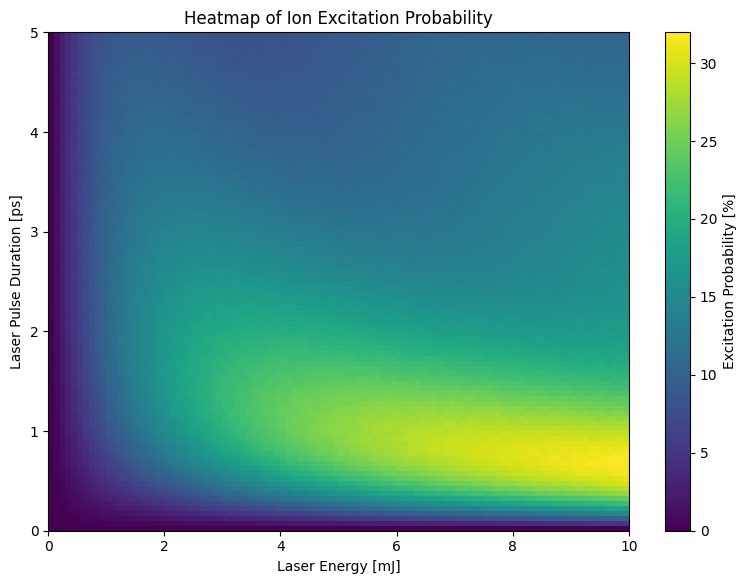

In [ ]:
# Plotting the fraction of excited ions as a heatmap
ions_list=lead,xenon,calcium
ion=lead

for ion in ions_list:# Ion properties:

    plt.figure()

    data = np.load(f'results/excitation/{ion.name}.npz')

    # Check the content of the file
    fraction_excited_array = data['fraction_excited_array']
    laser_energy_list = data['laser_energy_list']
    sigma_t_list = data['sigma_t_list']


    # Convert laser energies to mJ (1 J = 1000 mJ) and pulse durations to ps (1 s = 1e12 ps)
    laser_energy_mJ = np.array(laser_energy_list) * 1e3
    sigma_t_ps = np.array(sigma_t_list) * 1e12

    # Create the heatmap plot.
    plt.figure(figsize=(8, 6))

    # For imshow, set extent to map array indices to your physical values.
    extent = [laser_energy_mJ[0], laser_energy_mJ[-1], sigma_t_ps[0], sigma_t_ps[-1]]

    # Plot using imshow. origin='lower' ensures the lowest values appear at the bottom.
    img = plt.imshow(fraction_excited_array, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    plt.colorbar(img, label='Excitation Probability [%]')
    plt.xlabel('Laser Energy [mJ]')
    plt.ylabel('Laser Pulse Duration [ps]')
    plt.title('Heatmap of Ion Excitation Probability')
    plt.tight_layout()
    plt.show()



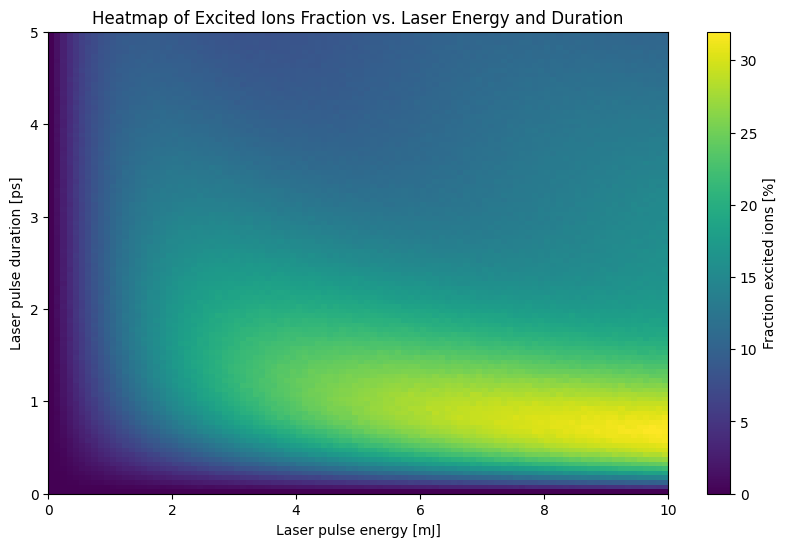

In [5]:
plt.figure(figsize=(10,6))

# Create the heatmap with the adjusted axes
plt.imshow(fraction_excited_array, aspect='auto', cmap='viridis', origin='lower',
           extent=[laser_energy_list[0] * 1e3, laser_energy_list[-1] * 1e3, sigma_t_list[0] * 1e12, sigma_t_list[-1] * 1e12])

# Add colorbar for better interpretation
plt.colorbar(label='Fraction excited ions [%]')

# Add labels and title
plt.xlabel('Laser pulse energy [mJ]')
plt.ylabel('Laser pulse duration [ps]')
plt.title('Heatmap of Excited Ions Fraction vs. Laser Energy and Duration')

plt.grid(False)
plt.show()